In [50]:
import matplotlib.pyplot as plt
import jupyter_black
import warnings

warnings.filterwarnings("ignore")
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import pandas as pd
import math
import numpy as np
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

jupyter_black.load()
import iris
import iris.quickplot as qplt
import iris.plot as iplt

In [51]:
import iris

cubes = iris.load("../Manabe-Climate-Model/_run_dir/model/atmos_r30_out.nc")

# 1. Extract both wind stress components
taux = cubes.extract_cube("taux")
tauy = cubes.extract_cube("tauy")

# 2. Compute vector magnitude: sqrt(taux^2 + tauy^2)
tau_mag = (taux**2 + tauy**2) ** 0.5

# 3. Set metadata
tau_mag.long_name = "wind stress magnitude"
tau_mag.var_name = "tau_mag"  # Prevents var_name from being None
tau_mag.units = taux.units  # Preserves units from taux/tauy

# 4. Append to list and sort
cubes.sort(key=lambda c: c.var_name or "")
cubes.append(tau_mag)

cubes

[<iris 'Cube' of surface albedo              / (percent) (latitude: 80; longitude: 96)>,
<iris 'Cube' of divergence spectral         / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of divergence spectral tau-1   / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of evaporation                 / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Packed cloud flags          / (unknown) (latitude: 80; longitude: 96)>,
<iris 'Cube' of liq. water flux into ocean  / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Precipitation               / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of sfc pressure spectral       / (dynes/cm**2) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of sfc pressure spectral tau-1 / (dynes/cm**2) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of total heat flux into ocean  / (cal/cm**2/s) (latitude: 80; longitude: 96)>,
<iris 'Cube' of mixing ratio spectral       / (unknown) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of mixing ratio spectral tau-1 / (unknown) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of radition ten spectral       / (C/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of runoff                      / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of SLWDP (see code for defin)  / (cal/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowfall on ocean           / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowfall                    / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snow depth                  / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of snowmelt                    / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of frz. water flux into ocean  / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of soil moisture               / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Sublimation                 / (cm/day) (latitude: 80; longitude: 96)>,
<iris 'Cube' of East-west wind stress       / (dyne/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of north-sth wind stress       / (dyne/cm**2) (latitude: 80; longitude: 96)>,
<iris 'Cube' of temperature spectral        / (C) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of temperature spectral tau-1  / (C) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of tmean (see code for defin)  / (K) (klevels : 18)>,
<iris 'Cube' of tmnshr(see code for defin)  / (K) (klevelsp: 19)>,
<iris 'Cube' of SST on atm grid             / (K) (latitude: 80; longitude: 96)>,
<iris 'Cube' of skin temperature            / (K) (latitude: 80; longitude: 96)>,
<iris 'Cube' of vorticity spectral          / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of vorticity spectral tau-1    / (cm**2/sec) (klevels : 18; nwave   : 32; mwave   : 62)>,
<iris 'Cube' of sea ice thickness           / (cm) (latitude: 80; longitude: 96)>,
<iris 'Cube' of Ycemlt (see code for defin) / (cm/sec) (latitude: 80; longitude: 96)>,
<iris 'Cube' of zstar        spectral       / (cm) (nwave   : 32; mwave   : 62)>,
<iris 'Cube' of wind stress magnitude / (dyne/cm**2) (latitude: 80; longitude: 96)>]

In [52]:
pd.DataFrame(
    [{"Long Name": cube.long_name, "Var Name": cube.var_name} for cube in cubes]
)

,Long Name,Var Name
0,surface albedo,calb
1,divergence spectral,div
2,divergence spectral tau-1,divm
3,evaporation,evapor
4,Packed cloud flags,kflags
5,liq. water flux into ocean,per
6,Precipitation,precip
7,sfc pressure spectral,psln
8,sfc pressure spectral tau-1,pslnm
9,total heat flux into ocean,qao


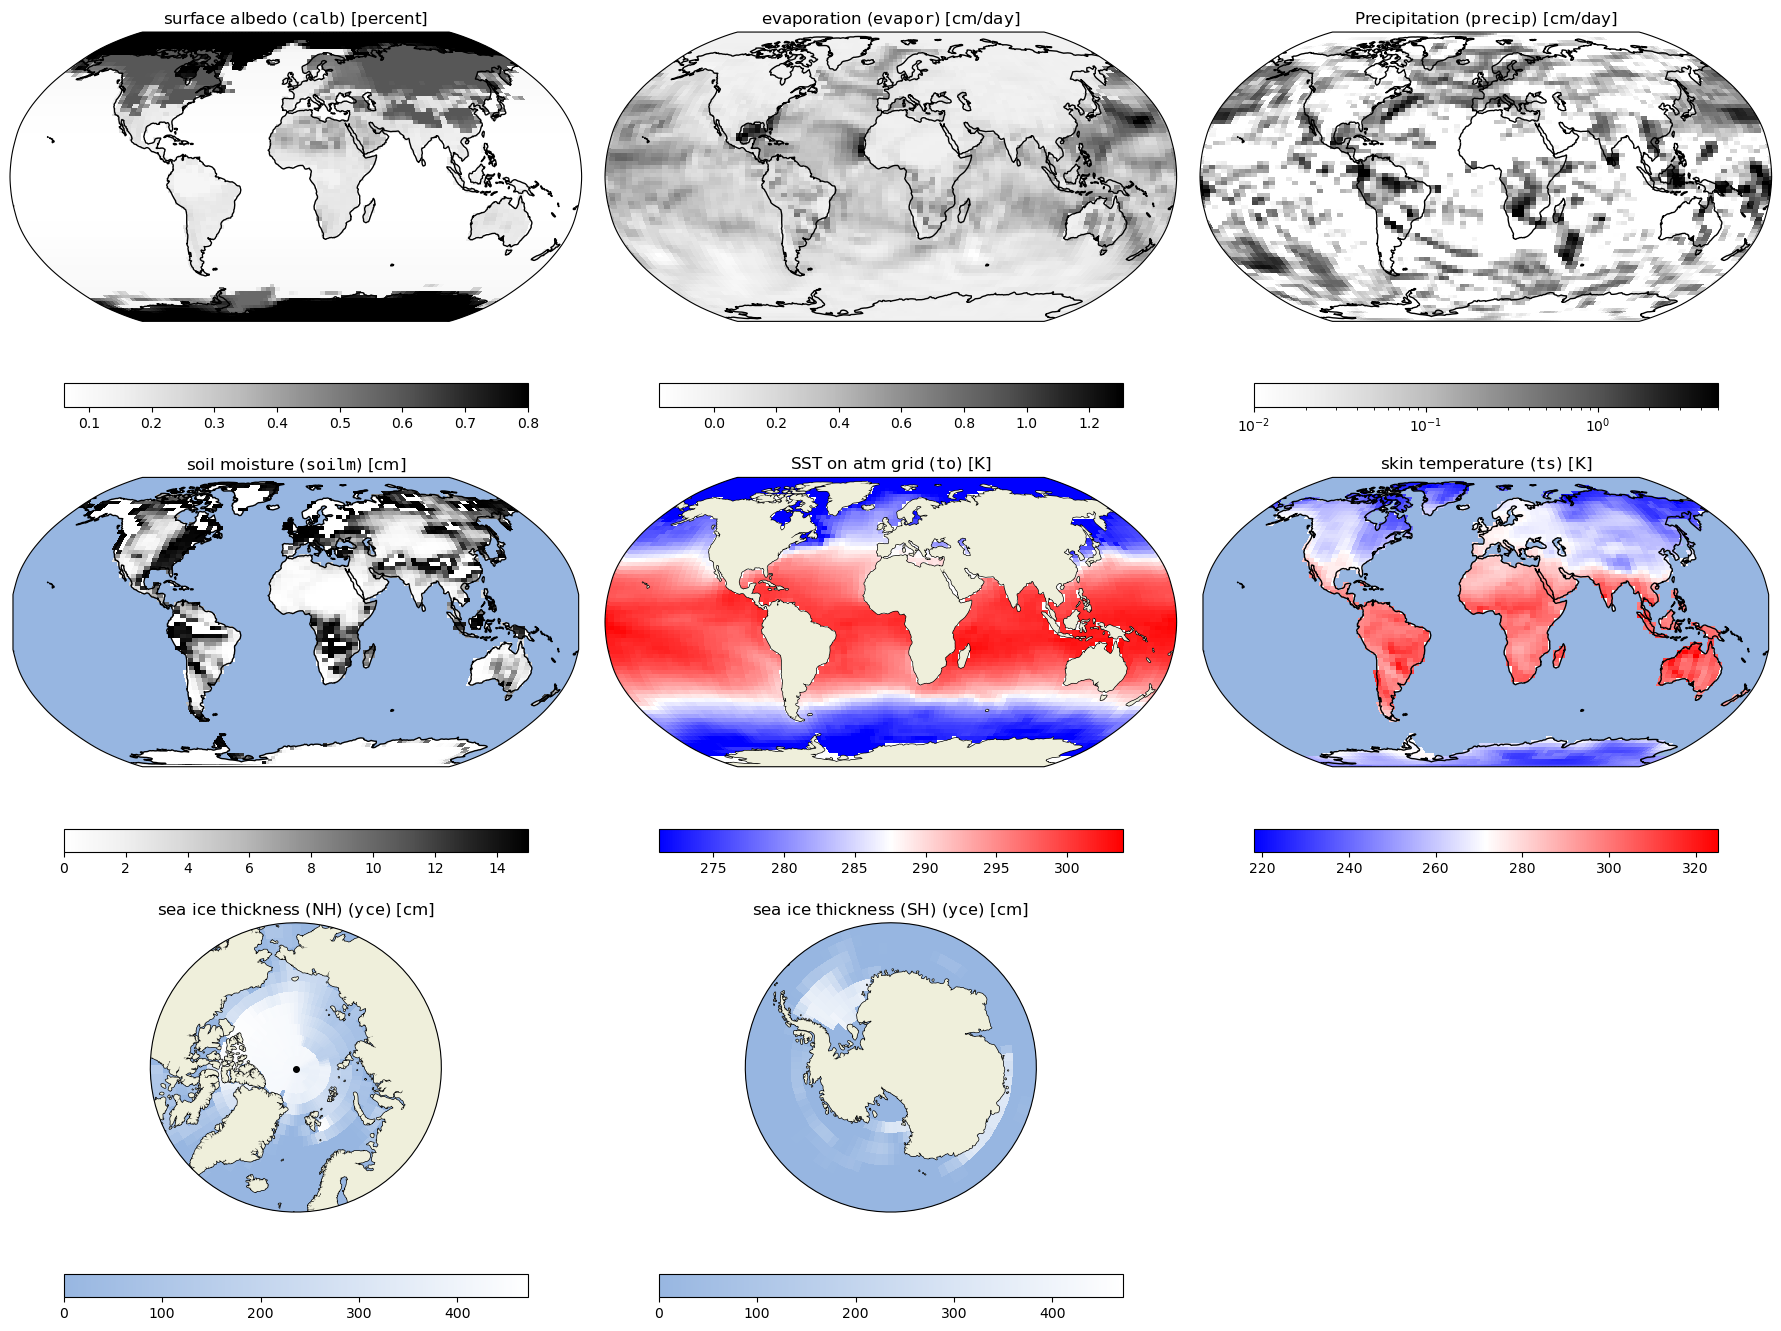

In [77]:
ocean_color = cfeature.OCEAN.kwargs["facecolor"]

cmap_ocean_to_white = LinearSegmentedColormap.from_list(
    "OceanToWhite", [ocean_color, "#ffffff"]
)

# Build a list of (cube_index, region) tasks
plot_tasks = []
for i, cube in enumerate(cubes):
    if not cube.coords("latitude"):
        continue
    if "tau" in (cube.var_name or "").lower() or any(
        word in (cube.long_name or "").lower()
        for word in (
            "melt",
            "mlt",
            "snow",
            "cloud",
            "slwdp",
            "tau",
            "flux",
            "sublimation",
            "runoff",
        )
    ):
        continue

    var = cube.var_name or ""
    if "yce" in var.lower():
        plot_tasks.append((i, "NH"))
        plot_tasks.append((i, "SH"))
    else:
        plot_tasks.append((i, "global"))

ncols = 3
nrows = math.ceil(len(plot_tasks) / ncols)

fig = plt.figure(figsize=(6 * ncols, 4.5 * nrows))

# Pre-compute the circular boundary path for reuse
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle_boundary = mpath.Path(verts * radius + center)

for i, (index, region) in enumerate(plot_tasks):
    plotthis = cubes[index]
    var = plotthis.var_name or ""

    # Pick projection based on region
    if region == "NH":
        proj = ccrs.NorthPolarStereo()
    elif region == "SH":
        proj = ccrs.SouthPolarStereo()
    else:
        proj = ccrs.Robinson()

    ax = fig.add_subplot(nrows, ncols, i + 1, projection=proj)

    # Apply polar circular boundaries & extent bounds
    if region == "NH":
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_boundary, transform=ax.transAxes)
    elif region == "SH":
        ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_boundary, transform=ax.transAxes)

    # Data masks
    if var == "to" and not np.ma.is_masked(plotthis.data):
        plotthis.data = np.ma.masked_values(plotthis.data, 273.16)
    if var == "ts" and not np.ma.is_masked(plotthis.data):
        plotthis.data = np.ma.masked_where(plotthis.data < 0, plotthis.data)
    if var == "soilm" and not np.ma.is_masked(plotthis.data):
        plotthis.data = np.ma.masked_where(plotthis.data == 15, plotthis.data)
    if var in ("sublim", "qao") and not np.ma.is_masked(plotthis.data):
        plotthis.data = np.ma.masked_where(plotthis.data == -0.0, plotthis.data)

    lat = plotthis.coord("latitude").points
    lon = plotthis.coord("longitude").points

    cmap = "bwr" if var in ("to", "ts") else "Greys"

    # Fixed: Assigned the variable object instead of a string
    if "sea ice" in (plotthis.long_name or "").lower():
        cmap = cmap_ocean_to_white

    ax.coastlines()

    long_name_clean = (plotthis.long_name or "").rstrip()
    var_code = var.replace("_", r"\_")

    # Append hemisphere identifier to title if polar
    region_label = f" ({region})" if region in ("NH", "SH") else ""
    ax.set_title(
        f"{long_name_clean}{region_label} ($\mathtt {{{var_code}}}$) [{plotthis.units}]"
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        plotthis.data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=(
            LogNorm(vmin=0.01, vmax=5)
            if "precip" in (plotthis.long_name or "").lower()
            else None
        ),
    )

    if region == "NH":
        ax.plot(
            0,
            90,
            marker="o",
            color="black",
            markersize=4,
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

    if any(term in (plotthis.long_name or "").lower() for term in ("sst", "sea ice")):
        ax.add_feature(cfeature.LAND, zorder=2)
    if any(
        term in (plotthis.long_name or "").lower()
        for term in ("skin temp", "soil", "sea ice")
    ):
        ax.add_feature(cfeature.OCEAN, zorder=0)

    fig.colorbar(mesh, ax=ax, orientation="horizontal", shrink=0.8)

plt.tight_layout()
plt.show()